In [1]:
import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt
import scipy
from sandbox.jordan5 import setup_device
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sandbox.jordan8 import *

import json

In [2]:
from sandbox.plt_dict import matplotlib_update
matplotlib_update()

In [3]:
device = setup_device()

torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

# Training from scratch

In [4]:
model = JordanNet(encode_dim=32)

training_dimensions = [4, 6, 9, 12, 15, 28]
for d in training_dimensions:
    model.add_dimension(d)

training_dataset = generate_training_datasets(matrices_per_class=2000,
                                              dimensions=training_dimensions, 
                                              normalize=True)

model = train_jordan_net(
    model,
    training_dataset,
    num_epochs=40, 
    batch_size=64,
    lr=4e-4,
    device=device,
    train_transformer=True,
    patience=8,
)

Generating class with d=4, max_block_size=1...

Done.
Generating class with d=4, max_block_size=2...Done.
Generating class with d=4, max_block_size=3...Done.
Generating class with d=4, max_block_size=4...Done.
Generating class with d=6, max_block_size=1...Done.
Generating class with d=6, max_block_size=2...Done.
Generating class with d=6, max_block_size=3...Done.
Generating class with d=6, max_block_size=4...Done.
Generating class with d=6, max_block_size=5...Done.
Generating class with d=6, max_block_size=6...Done.
Generating class with d=9, max_block_size=1...Done.
Generating class with d=9, max_block_size=2...Done.
Generating class with d=9, max_block_size=3...Done.
Generating class with d=9, max_block_size=4...Done.
Generating class with d=9, max_block_size=5...Done.
Generating class with d=9, max_block_size=6...Done.
Generating class with d=9, max_block_size=7...Done.
Generating class with d=9, max_block_size=8...Done.
Generating class with d=9, max_block_size=9...Done.
Generating class with d=12, max_block_size=1...Done.
Gener

c:\Users\micha\Documents\Studia\Magisterka\venv\Lib\site-packages\torch\nn\functional.py:3006: UserWarning: The operator 'aten::xlogy.OutTensor' is not currently supported on the DML backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at C:\__w\1\s\pytorch-directml-plugin\torch_directml\csrc\dml\dml_cpu_fallback.cpp:17.)
  reduced = torch.kl_div(input, target, reduction_enum, log_target=log_target)


Epoch [1/40] | Train Loss: 0.981242 | Val Loss: 0.902346 | LR: 3.99e-04
Epoch [2/40] | Train Loss: 0.410151 | Val Loss: 0.670823 | LR: 3.98e-04
Epoch [3/40] | Train Loss: 0.307586 | Val Loss: 0.423044 | LR: 3.94e-04
Epoch [4/40] | Train Loss: 0.271445 | Val Loss: 0.375889 | LR: 3.90e-04
Epoch [5/40] | Train Loss: 0.252548 | Val Loss: 0.509572 | LR: 3.85e-04
Epoch [6/40] | Train Loss: 0.251137 | Val Loss: 0.481322 | LR: 3.78e-04
Epoch [7/40] | Train Loss: 0.266682 | Val Loss: 0.582288 | LR: 3.71e-04
Epoch [8/40] | Train Loss: 0.221892 | Val Loss: 0.296970 | LR: 3.62e-04
Epoch [9/40] | Train Loss: 0.204545 | Val Loss: 0.371212 | LR: 3.52e-04
Epoch [10/40] | Train Loss: 0.231616 | Val Loss: 0.663641 | LR: 3.41e-04
Epoch [11/40] | Train Loss: 0.196173 | Val Loss: 0.275926 | LR: 3.30e-04
Epoch [12/40] | Train Loss: 0.182295 | Val Loss: 0.325317 | LR: 3.18e-04
Epoch [13/40] | Train Loss: 0.174135 | Val Loss: 0.305350 | LR: 3.04e-04
Epoch [14/40] | Train Loss: 0.166315 | Val Loss: 0.325139 | 

c:\Users\micha\Documents\Studia\Magisterka\sandbox\jordan8.py:462: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(filename))


# Tests

In [5]:
def run_test(model, d, matrices_per_class=1000, mode="random", eps=None, eps_range=None):
    model.eval()

    training_dataset = generate_training_datasets(
        matrices_per_class=matrices_per_class,
        dimensions=[d],
        mode=mode,
        eps=eps,
        eps_range=eps_range,
        device="cpu",
        normalize=True,
    )
    matrices, labels, features, dists = training_dataset[d]
    loader = DataLoader(TensorDataset(features, labels, dists), batch_size=64, shuffle=False)

    predicted_classes = []
    true_classes = labels.cpu().tolist()
    kl_avg = 0.0

    for batch_features, batch_labels, batch_dists in loader:
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)
        batch_dists = batch_dists.to(device)

        logits = model(d, batch_features)
        loss = kl_loss(logits, batch_dists)

        preds = torch.argmax(logits, dim=-1)
        predicted_classes += preds.cpu().tolist()
        kl_avg += loss.item() * batch_features.size(0)

    kl_avg /= len(loader.dataset)
    # print(f"Test KL Loss: {kl_avg:.6f}")

    return true_classes, predicted_classes, kl_avg

def test_jordan_net(model, d, matrices_per_class=1000, filename=None):
    if filename is None:
        filename = f"sandbox/jordan8_results/results_{d}.json"

    results = []

    for eps in [0.0, 1e-6, 1e-4, 1e-2, 1e-1, 1]:
        print(f"Testing with eps={eps}")
        true_classes, predicted_classes, kl_avg = run_test(model, d, matrices_per_class=matrices_per_class, mode="random", eps=eps)
        results.append({
            "eps": eps,
            "true_classes": true_classes,
            "predicted_classes": predicted_classes,
            "kl_avg": kl_avg,
        })
    
    # print(f"Testing mode 'ortho'")
    # true_classes, predicted_classes, kl_avg = run_test(model, d, matrices_per_class=matrices_per_class, mode="ortho", eps=0.0)
    # results.append({
    #     "eps": "ortho",
    #     "true_classes": true_classes,
    #     "predicted_classes": predicted_classes,
    #     "kl_avg": kl_avg,
    # })
    with open(filename, "w") as f:
        json.dump(results, f, indent=4)
    
def visualize_test_results(d, filename):
    with open(filename, "r") as f:
        results = json.load(f) 
    
    for result in results:
        eps = result["eps"]
        true_classes = result["true_classes"]
        predicted_classes = result["predicted_classes"]
        
        cm = confusion_matrix(true_classes, predicted_classes, labels=list(range(d)))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(1, d+1)))
        disp.plot(cmap=plt.cm.Blues)
        title = f"{'eps='+str(eps) if eps != 'ortho' else 'ortho'}. KL Loss: {result['kl_avg']:.6f}, accuracy: {np.trace(cm) / np.sum(cm):.4f}"
        plt.title(title)
        plt.show()
    
def print_test_results(d, filename):
    with open(filename, "r") as f:
        results = json.load(f)

    print(f"\nTest results for dimension {d}:") 
    
    for result in results:
        eps = result["eps"]
        true_classes = result["true_classes"]
        predicted_classes = result["predicted_classes"]
        
        cm = confusion_matrix(true_classes, predicted_classes, labels=list(range(d)))
        title = f"\t{'eps='+f'{eps:<10}' if eps != 'ortho' else 'ortho     '}\t KL Loss: {result['kl_avg']:.6f},\t accuracy: {np.trace(cm) / np.sum(cm):.4f}"
        print(title)

In [6]:
model = JordanNet(encode_dim=32)
training_dimensions = [4, 6, 9, 12, 15, 28]
for d in training_dimensions:
    model.add_dimension(d)
model.load_state_dict(torch.load(f"sandbox/model_jordan8.pth"))
model.to(device)
for d in training_dimensions:
    test_jordan_net(model, d, matrices_per_class=1000)

Testing with eps=0.0
Generating class with d=4, max_block_size=1...

C:\Users\micha\AppData\Local\Temp\ipykernel_21020\2942514706.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"sandbox/model_jordan8.pth

Done.
Generating class with d=4, max_block_size=2...Done.
Generating class with d=4, max_block_size=3...Done.
Generating class with d=4, max_block_size=4...Done.
Testing with eps=1e-06
Generating class with d=4, max_block_size=1...Done.
Generating class with d=4, max_block_size=2...Done.
Generating class with d=4, max_block_size=3...Done.
Generating class with d=4, max_block_size=4...Done.
Testing with eps=0.0001
Generating class with d=4, max_block_size=1...Done.
Generating class with d=4, max_block_size=2...Done.
Generating class with d=4, max_block_size=3...Done.
Generating class with d=4, max_block_size=4...Done.
Testing with eps=0.01
Generating class with d=4, max_block_size=1...Done.
Generating class with d=4, max_block_size=2...Done.
Generating class with d=4, max_block_size=3...Done.
Generating class with d=4, max_block_size=4...Done.
Testing with eps=0.1
Generating class with d=4, max_block_size=1...Done.
Generating class with d=4, max_block_size=2...Done.
Generating class wit

In [7]:
for d in training_dimensions:
    print_test_results(d, f"sandbox/jordan8_results/results_{d}.json")


Test results for dimension 4:
	eps=0.0       	 KL Loss: 0.100800,	 accuracy: 0.0003
	eps=1e-06     	 KL Loss: 0.025430,	 accuracy: 0.0003
	eps=0.0001    	 KL Loss: 0.492594,	 accuracy: 0.0030
	eps=0.01      	 KL Loss: 0.355505,	 accuracy: 0.2633
	eps=0.1       	 KL Loss: 0.126258,	 accuracy: 0.4050
	eps=1         	 KL Loss: 0.077678,	 accuracy: 0.3337

Test results for dimension 6:
	eps=0.0       	 KL Loss: 0.150887,	 accuracy: 0.0002
	eps=1e-06     	 KL Loss: 0.050621,	 accuracy: 0.0010
	eps=0.0001    	 KL Loss: 0.460998,	 accuracy: 0.0042
	eps=0.01      	 KL Loss: 0.134777,	 accuracy: 0.3206
	eps=0.1       	 KL Loss: 0.075567,	 accuracy: 0.1328
	eps=1         	 KL Loss: 0.678520,	 accuracy: 0.0004

Test results for dimension 9:
	eps=0.0       	 KL Loss: 0.132705,	 accuracy: 0.0020
	eps=1e-06     	 KL Loss: 0.039863,	 accuracy: 0.0021
	eps=0.0001    	 KL Loss: 0.508886,	 accuracy: 0.0020
	eps=0.01      	 KL Loss: 0.058016,	 accuracy: 0.0560
	eps=0.1       	 KL Loss: 0.162819,	 accura

# Training + tests on additional dimensions

In [8]:
model = JordanNet(encode_dim=32).cpu()
pretrained_dimensions = [4, 6, 9, 12, 15, 28]
for d in pretrained_dimensions:
    model.add_dimension(d)

model.load_state_dict(torch.load(f"sandbox/model_jordan8.pth", map_location="cpu"))
model.to(device)

new_dimensions = [35, 33, 25, 23, 19, 13, 7]

for d in new_dimensions:
    model.add_dimension(d)
    training_dataset = generate_training_datasets(matrices_per_class=1200,
                                                dimensions=[d], normalize=True, numpy_float32=True)
    model = train_jordan_net(
        model,
        training_dataset,
        num_epochs=40,
        batch_size=64,
        patience=8,
        lr=4e-4,
        device=device,
        train_transformer=False,
        history_filename=f"sandbox/history_jordan8_{d}.csv")

Generating class with d=35, max_block_size=1...

C:\Users\micha\AppData\Local\Temp\ipykernel_21020\171642769.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"sandbox/model_jordan8.pth"

Done.
Generating class with d=35, max_block_size=2...Done.
Generating class with d=35, max_block_size=3...Done.
Generating class with d=35, max_block_size=4...Done.
Generating class with d=35, max_block_size=5...Done.
Generating class with d=35, max_block_size=6...Done.
Generating class with d=35, max_block_size=7...Done.
Generating class with d=35, max_block_size=8...Done.
Generating class with d=35, max_block_size=9...Done.
Generating class with d=35, max_block_size=10...Done.
Generating class with d=35, max_block_size=11...Done.
Generating class with d=35, max_block_size=12...Done.
Generating class with d=35, max_block_size=13...Done.
Generating class with d=35, max_block_size=14...Done.
Generating class with d=35, max_block_size=15...Done.
Generating class with d=35, max_block_size=16...Done.
Generating class with d=35, max_block_size=17...Done.
Generating class with d=35, max_block_size=18...Done.
Generating class with d=35, max_block_size=19...Done.
Generating class with d=35, ma

c:\Users\micha\Documents\Studia\Magisterka\sandbox\jordan8.py:462: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(filename))


Generating class with d=33, max_block_size=1...Done.
Generating class with d=33, max_block_size=2...Done.
Generating class with d=33, max_block_size=3...Done.
Generating class with d=33, max_block_size=4...Done.
Generating class with d=33, max_block_size=5...Done.
Generating class with d=33, max_block_size=6...Done.
Generating class with d=33, max_block_size=7...Done.
Generating class with d=33, max_block_size=8...Done.
Generating class with d=33, max_block_size=9...Done.
Generating class with d=33, max_block_size=10...Done.
Generating class with d=33, max_block_size=11...Done.
Generating class with d=33, max_block_size=12...Done.
Generating class with d=33, max_block_size=13...Done.
Generating class with d=33, max_block_size=14...Done.
Generating class with d=33, max_block_size=15...Done.
Generating class with d=33, max_block_size=16...Done.
Generating class with d=33, max_block_size=17...Done.
Generating class with d=33, max_block_size=18...Done.
Generating class with d=33, max_block

In [9]:
model = JordanNet(encode_dim=32).cpu()
pretrained_dimensions = [4, 6, 9, 12, 15, 28]
for d in pretrained_dimensions:
    model.add_dimension(d)

new_dimensions = [35, 33, 25, 23, 19, 13, 7]

for d in new_dimensions:
    model.add_dimension(d)


model.load_state_dict(torch.load(f"sandbox/model_jordan8_modified.pth", map_location="cpu"))
model.to(device)

C:\Users\micha\AppData\Local\Temp\ipykernel_21020\3686752702.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"sandbox/model_jordan8_mo

JordanNet(
  (encoders): ModuleDict(
    (4): MatrixEncoder(
      (net): Sequential(
        (0): Linear(in_features=16, out_features=128, bias=True)
        (1): ReLU()
        (2): Linear(in_features=128, out_features=128, bias=True)
        (3): ReLU()
        (4): Linear(in_features=128, out_features=128, bias=True)
        (5): ReLU()
        (6): Linear(in_features=128, out_features=32, bias=True)
      )
    )
    (6): MatrixEncoder(
      (net): Sequential(
        (0): Linear(in_features=36, out_features=128, bias=True)
        (1): ReLU()
        (2): Linear(in_features=128, out_features=128, bias=True)
        (3): ReLU()
        (4): Linear(in_features=128, out_features=128, bias=True)
        (5): ReLU()
        (6): Linear(in_features=128, out_features=32, bias=True)
      )
    )
    (9): MatrixEncoder(
      (net): Sequential(
        (0): Linear(in_features=81, out_features=128, bias=True)
        (1): ReLU()
        (2): Linear(in_features=128, out_features=128, bias

In [10]:
for d in new_dimensions:
    test_jordan_net(model, d, matrices_per_class=1000)

Testing with eps=0.0
Generating class with d=35, max_block_size=1...Done.
Generating class with d=35, max_block_size=2...Done.
Generating class with d=35, max_block_size=3...Done.
Generating class with d=35, max_block_size=4...Done.
Generating class with d=35, max_block_size=5...Done.
Generating class with d=35, max_block_size=6...Done.
Generating class with d=35, max_block_size=7...Done.
Generating class with d=35, max_block_size=8...Done.
Generating class with d=35, max_block_size=9...Done.
Generating class with d=35, max_block_size=10...Done.
Generating class with d=35, max_block_size=11...Done.
Generating class with d=35, max_block_size=12...Done.
Generating class with d=35, max_block_size=13...Done.
Generating class with d=35, max_block_size=14...Done.
Generating class with d=35, max_block_size=15...Done.
Generating class with d=35, max_block_size=16...Done.
Generating class with d=35, max_block_size=17...Done.
Generating class with d=35, max_block_size=18...Done.
Generating class

In [11]:
for d in new_dimensions:
    print_test_results(d, f"sandbox/jordan8_results/results_{d}.json")


Test results for dimension 35:
	eps=0.0       	 KL Loss: 0.240449,	 accuracy: 0.0121
	eps=1e-06     	 KL Loss: 0.057606,	 accuracy: 0.0132
	eps=0.0001    	 KL Loss: 0.513698,	 accuracy: 0.0149
	eps=0.01      	 KL Loss: 0.590573,	 accuracy: 0.1486
	eps=0.1       	 KL Loss: 0.987997,	 accuracy: 0.1404
	eps=1         	 KL Loss: 2.981326,	 accuracy: 0.0269

Test results for dimension 33:
	eps=0.0       	 KL Loss: 0.259851,	 accuracy: 0.0067
	eps=1e-06     	 KL Loss: 0.065599,	 accuracy: 0.0073
	eps=0.0001    	 KL Loss: 0.475662,	 accuracy: 0.0093
	eps=0.01      	 KL Loss: 0.814064,	 accuracy: 0.0846
	eps=0.1       	 KL Loss: 1.509520,	 accuracy: 0.1003
	eps=1         	 KL Loss: 4.148721,	 accuracy: 0.0285

Test results for dimension 25:
	eps=0.0       	 KL Loss: 0.230262,	 accuracy: 0.0083
	eps=1e-06     	 KL Loss: 0.035253,	 accuracy: 0.0066
	eps=0.0001    	 KL Loss: 0.430919,	 accuracy: 0.0090
	eps=0.01      	 KL Loss: 0.829305,	 accuracy: 0.0621
	eps=0.1       	 KL Loss: 0.968733,	 acc

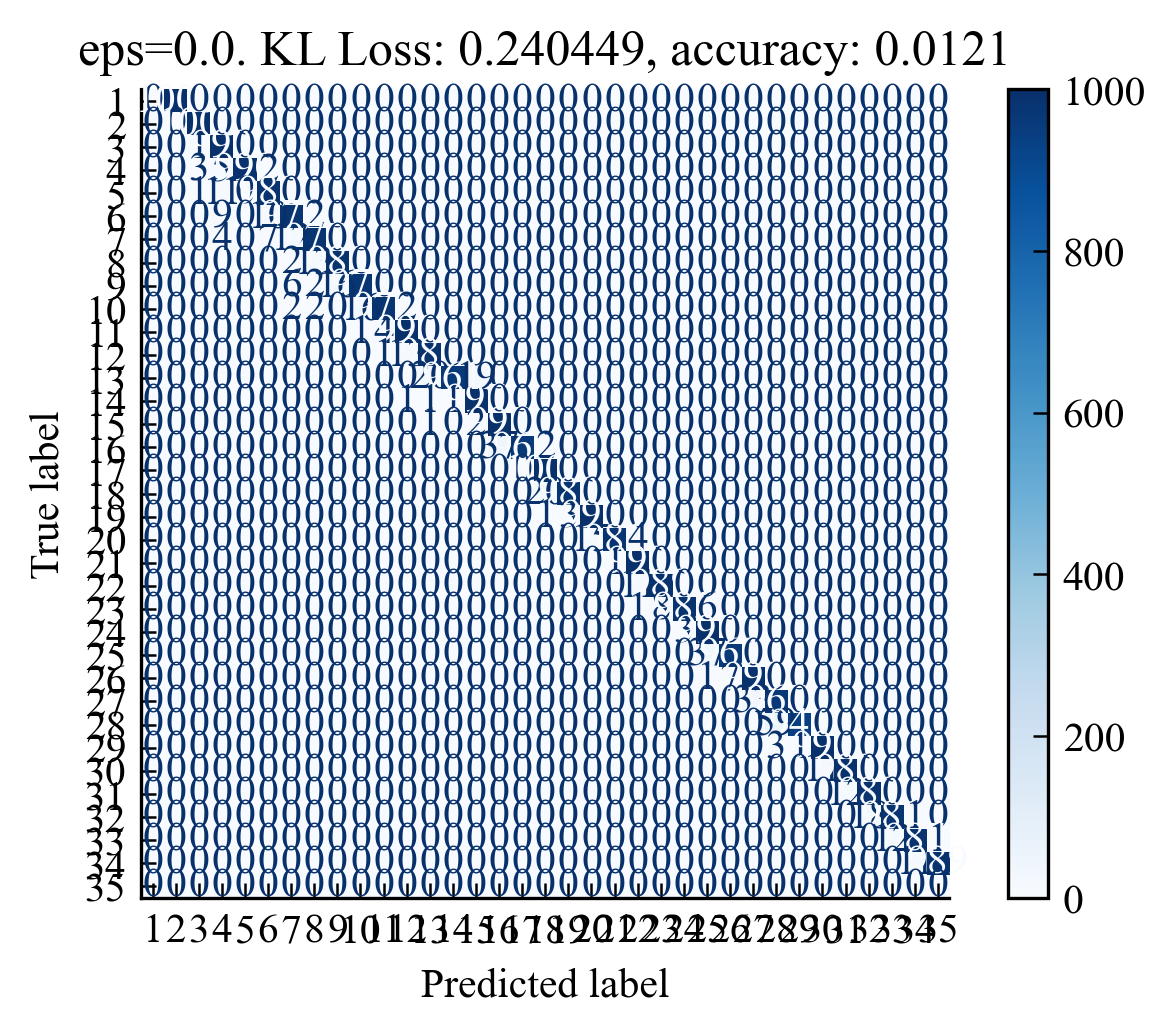

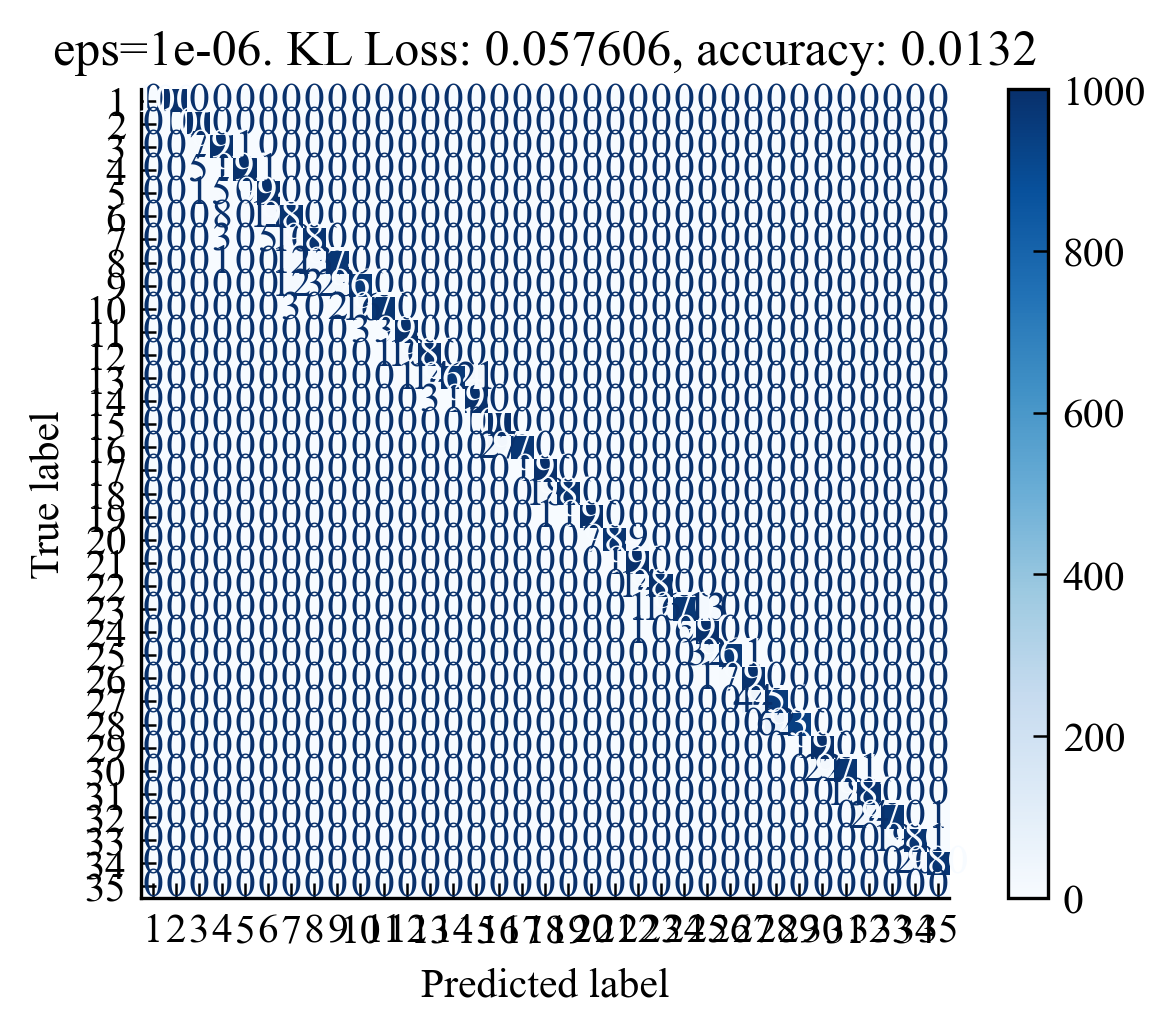

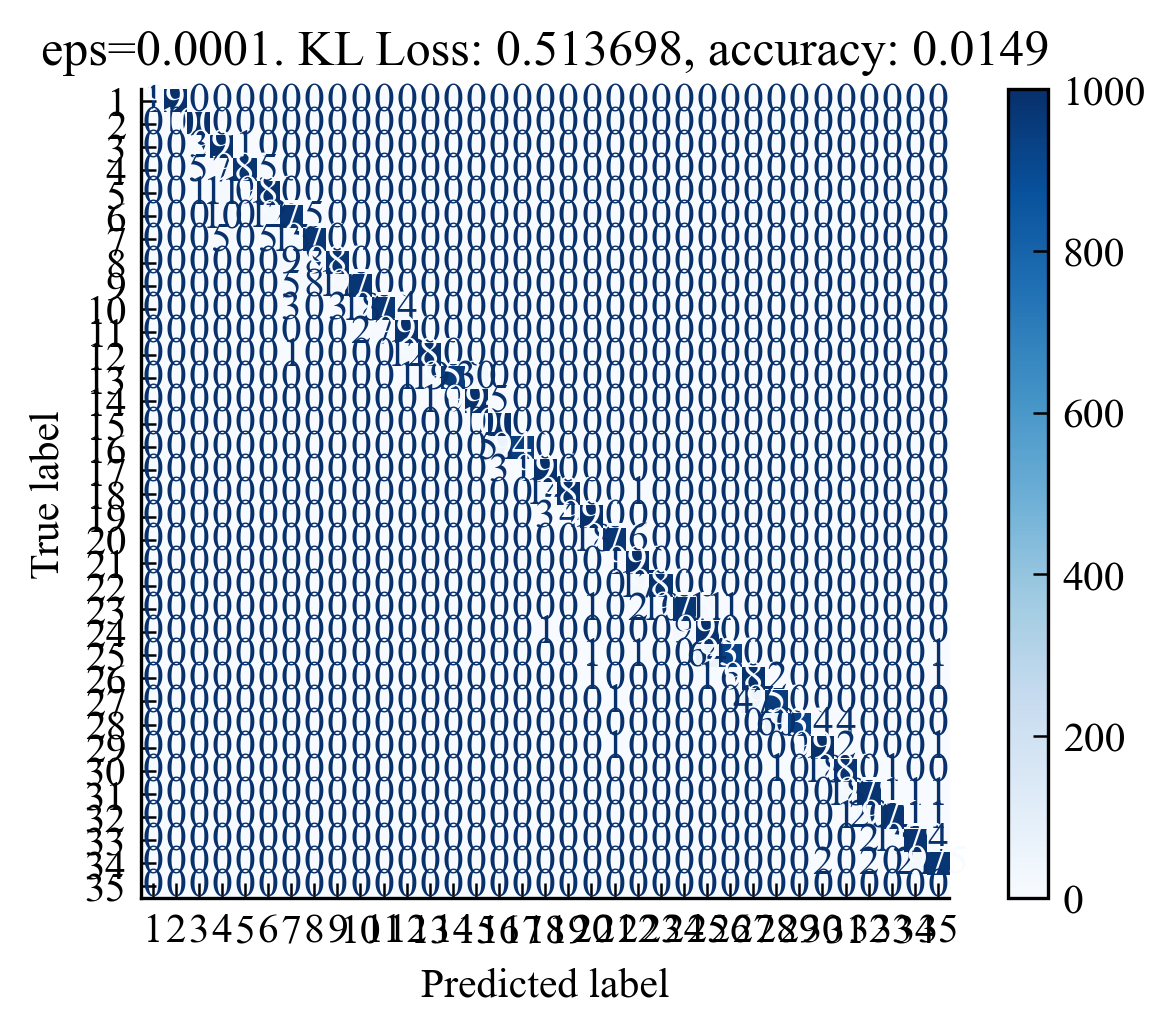

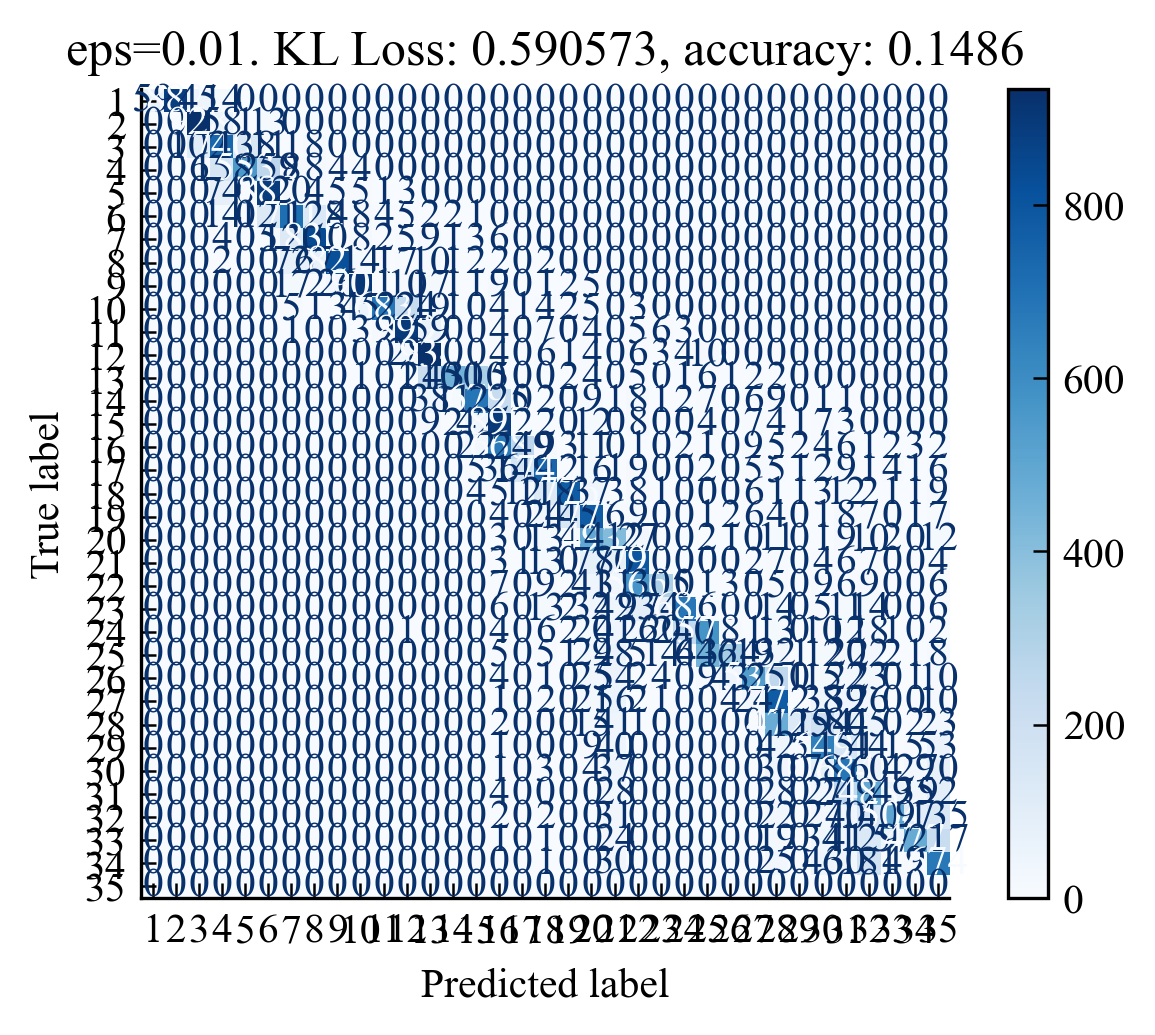

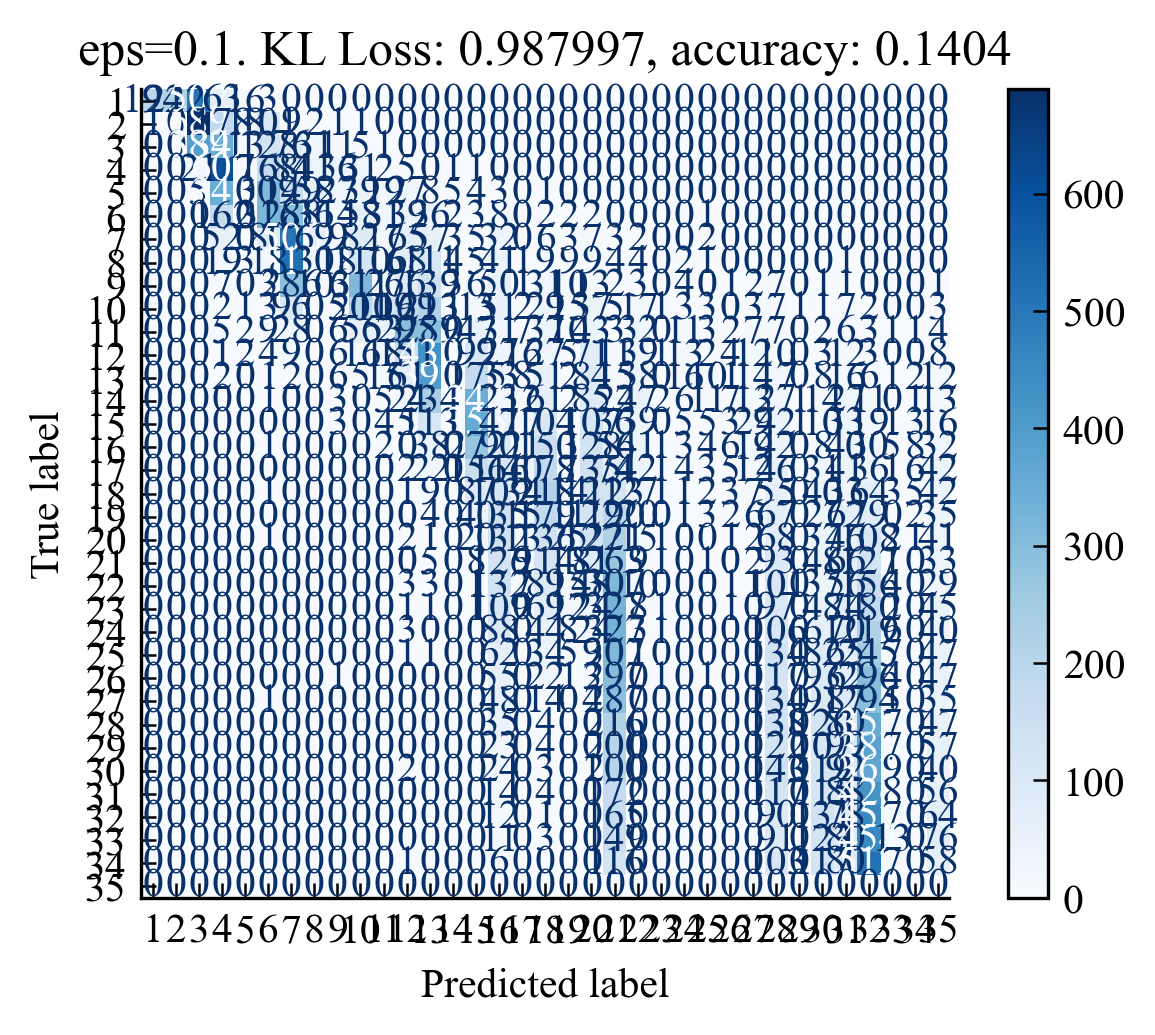

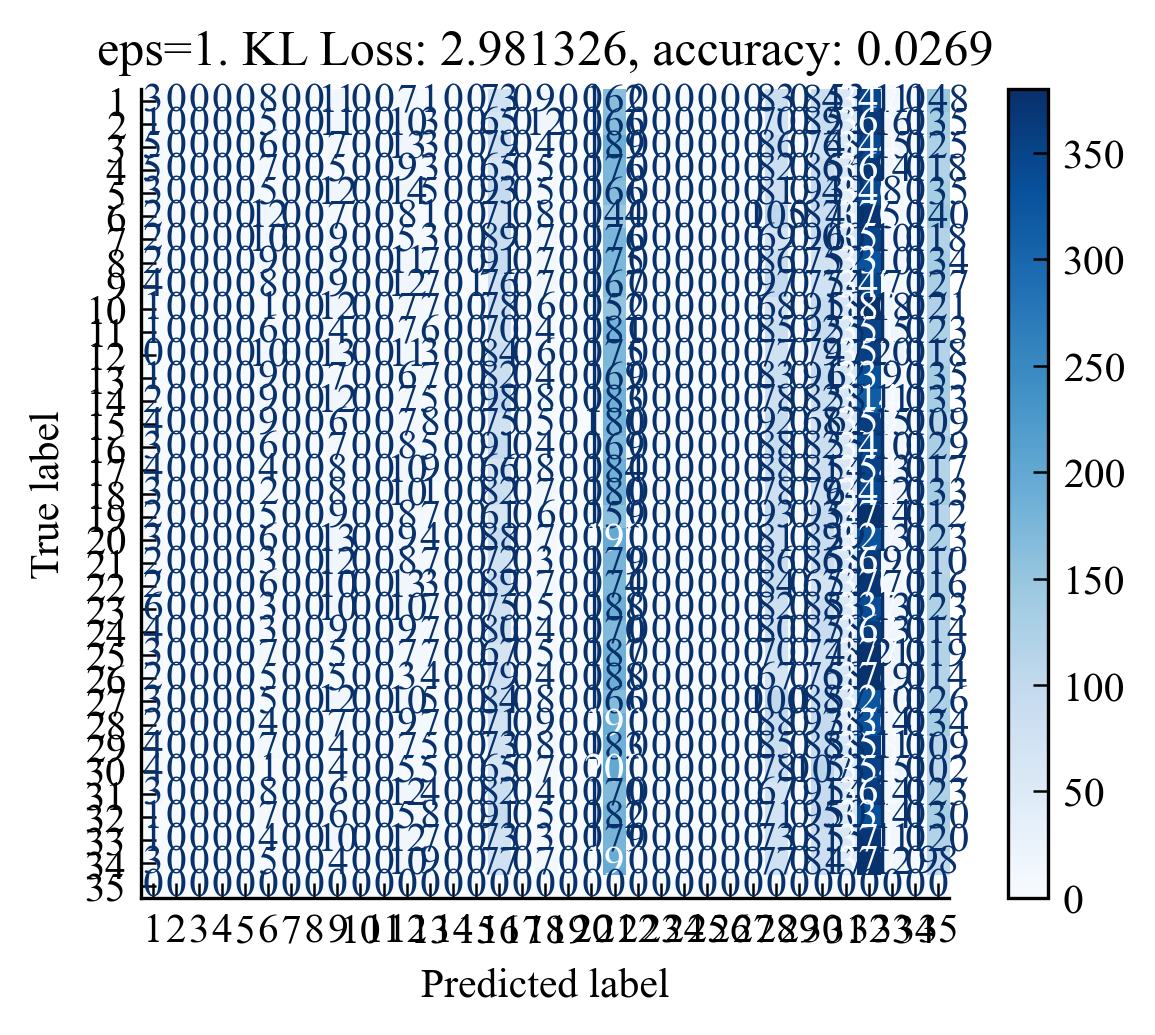

In [12]:
visualize_test_results(35, f"sandbox/jordan8_results/results_35.json")

# Test results comparison

In [13]:
def _load_state(path):
    sd = torch.load(path, map_location="cpu")
    # handle common checkpoint wrappers
    if isinstance(sd, dict) and ("state_dict" in sd or "model_state_dict" in sd):
        sd = sd.get("state_dict", sd.get("model_state_dict"))
    return sd

def _is_transformer_key(k):
    kl = k.lower()
    tokens = ("transformer", "transf", "encoder", "attn", "self_attn", "multihead", "mha", "ffn", "feed_forward")
    return any(t in kl for t in tokens)

p1 = "sandbox/model_jordan8.pth"
p2 = "sandbox/model_jordan8_modified.pth"

sd1 = _load_state(p1)
sd2 = _load_state(p2)

keys1 = set(sd1.keys())
keys2 = set(sd2.keys())

# collect transformer-related keys present in either checkpoint
t_keys = sorted(k for k in (keys1 | keys2) if _is_transformer_key(k))

if not t_keys:
    print("No transformer-related parameter names found in checkpoints.")
else:
    all_identical = True
    for k in t_keys:
        in1 = k in sd1
        in2 = k in sd2
        if not (in1 and in2):
            print(f"Mismatch presence: '{k}' only in", p1 if in1 else p2)
            all_identical = False
            continue

        a = sd1[k]
        b = sd2[k]
        if a.shape != b.shape:
            print(f"Shape differs for '{k}': {a.shape} vs {b.shape}")
            all_identical = False
            continue

        equal = torch.equal(a, b)
        max_abs = (a - b).abs().max().item() if a.numel() > 0 else 0.0
        mean_abs = (a - b).abs().mean().item() if a.numel() > 0 else 0.0
        status = "IDENTICAL" if equal else "DIFFER"
        print(f"{status}: {k} | max_abs={max_abs:.6e}, mean_abs={mean_abs:.6e}")
        if not equal:
            all_identical = False


IDENTICAL: encoders.12.net.0.bias | max_abs=0.000000e+00, mean_abs=0.000000e+00
IDENTICAL: encoders.12.net.0.weight | max_abs=0.000000e+00, mean_abs=0.000000e+00
IDENTICAL: encoders.12.net.2.bias | max_abs=0.000000e+00, mean_abs=0.000000e+00
IDENTICAL: encoders.12.net.2.weight | max_abs=0.000000e+00, mean_abs=0.000000e+00
IDENTICAL: encoders.12.net.4.bias | max_abs=0.000000e+00, mean_abs=0.000000e+00
IDENTICAL: encoders.12.net.4.weight | max_abs=0.000000e+00, mean_abs=0.000000e+00
IDENTICAL: encoders.12.net.6.bias | max_abs=0.000000e+00, mean_abs=0.000000e+00
IDENTICAL: encoders.12.net.6.weight | max_abs=0.000000e+00, mean_abs=0.000000e+00
Mismatch presence: 'encoders.13.net.0.bias' only in sandbox/model_jordan8_modified.pth
Mismatch presence: 'encoders.13.net.0.weight' only in sandbox/model_jordan8_modified.pth
Mismatch presence: 'encoders.13.net.2.bias' only in sandbox/model_jordan8_modified.pth
Mismatch presence: 'encoders.13.net.2.weight' only in sandbox/model_jordan8_modified.pth


C:\Users\micha\AppData\Local\Temp\ipykernel_21020\3512677630.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(path, map_location="cpu")


C:\Users\micha\AppData\Local\Temp\ipykernel_21020\2875399437.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"sandbox/model_jordan8_mo

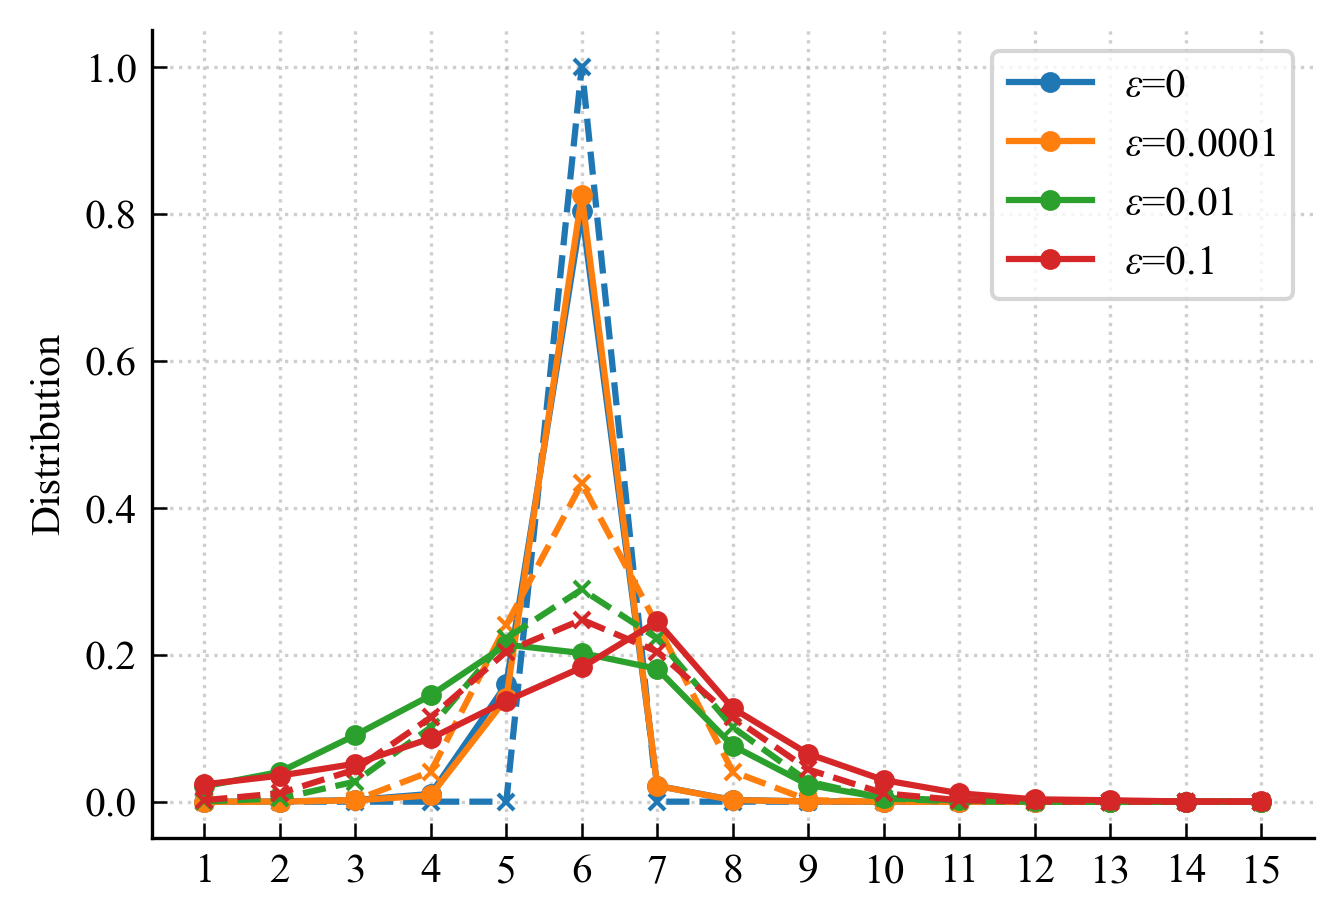

In [15]:
max_block_size = 6
dtype = np.float32
d = 15

model = JordanNet(encode_dim=32).cpu()
pretrained_dimensions = [4, 6, 9, 12, 15, 28] + [35, 33, 25, 23, 19, 13, 7]
for dim in pretrained_dimensions:
    model.add_dimension(dim)

model.load_state_dict(torch.load(f"sandbox/model_jordan8_modified.pth", map_location="cpu"))
model.cpu()
model.eval()

epsilons = [0, 1e-4, 1e-2, 1e-1]

Xs = [generate_matrix(d, max_block_size, mode="random", eps=eps)[0] for eps in epsilons]
X_batch = torch.tensor(Xs, dtype=torch.float32)
features = [per_power_features(X) for X in Xs]
X_features = torch.tensor(features, dtype=torch.float32)

logits = model(d, X_features)
probs = torch.softmax(logits, dim=-1)
probs = probs.detach().cpu().numpy()

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

for i, (prob, eps) in enumerate(zip(probs, epsilons)):
    c = colors[i % len(colors)]
    plt.plot(soft_target(torch.tensor([max_block_size]), eps=torch.tensor(eps), d=d).cpu().numpy(), marker='x', linestyle='--', color=c)
    plt.plot(prob, label=f"$\\varepsilon$={eps}", marker='o', linestyle='-', color=c)

plt.legend()
plt.xticks(ticks=range(d), labels=range(1,d+1))
#plt.xlim(6,16)
plt.ylabel("Distribution")
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig("latex/images/j8_target_eample.pdf")
plt.show()
    